# Convergent Probe CBED — Au [110]

Accuracy of each propagation method as a function of probe convergence semi-angle.

- **Ground truth**: KG ODE (full second-order) with 128×128×128 finely sampled potential
- **Test methods**: Fresnel MS, Angular Spectrum, WPM, KG FWD Lanczos (fixed 32 slices/cell)
- **Probe angles**: 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100 mrad
- **Crystal**: Au [110], 200 keV, ~100 unit cells thick
- **Metric**: Relative L2 norm of diffraction pattern vs ODE ground truth

In [1]:
%matplotlib inline

import os
from time import perf_counter
import functools

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk, surface
from matplotlib.colors import LogNorm

from wide_angle_propagation.propagation_methods import (
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_wpm_jit,
    simulate_kg_ode_full,
)
from wide_angle_propagation.propagation_methods import _lanczos_expsqrt

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

## Build crystal, potentials, and helpers

In [2]:
# --- Parameters ---
energy = 200e3
a_Au = 4.076

# --- Build Au [110] orthogonal cell ---
au_bulk = bulk("Au", "fcc", a=a_Au)
au_110 = surface(au_bulk, (1, 1, 0), layers=2)
unit_cell = abtem.orthogonalize_cell(au_110)

z_period = a_Au / np.sqrt(2)
unit_cell.cell[2, 2] = z_period
unit_cell.pbc = [True, True, True]

nx_rep = int(np.ceil(10 / unit_cell.cell.lengths()[0]))
ny_rep = int(np.ceil(10 / unit_cell.cell.lengths()[1]))
nz_rep = int(np.ceil(100 / z_period))

supercell = unit_cell * (nx_rep, ny_rep, nz_rep)
total_thickness = float(supercell.cell[2, 2])
wavelength = float(energy2wavelength(energy))

# --- ODE reference grid: 128×128 lateral, 128 slices/cell ---
ODE_GPTS = (128, 128)
ODE_SLICES_PER_CELL = 128

semi_angle_mrad = np.array([5, 10, 30, 50, 60, 70, 80, 90, 100, 150, 200, 300], dtype=float)

# --- Z-sampling ---
TEST_SLICES_PER_CELL = 32

dz_ode = z_period / ODE_SLICES_PER_CELL
dz_test = z_period / TEST_SLICES_PER_CELL

print(f"Au [110], {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Unit cell z-period = {z_period:.4f} Å")
print(f"Supercell: {nx_rep}×{ny_rep}×{nz_rep}, total thickness = {total_thickness:.1f} Å")
print(f"\nConvergence semi-angles: {semi_angle_mrad} mrad")
print(f"ODE ground truth: gpts={ODE_GPTS}, dz = {dz_ode:.4f} Å ({ODE_SLICES_PER_CELL} slices/cell)")
print(f"Test methods:     dz = {dz_test:.4f} Å ({TEST_SLICES_PER_CELL} slices/cell)")

Au [110], 200 keV, λ = 0.0251 Å
Unit cell z-period = 2.8822 Å
Supercell: 4×4×35, total thickness = 100.9 Å

Convergence semi-angles: [  5.  10.  30.  50.  60.  70.  80.  90. 100. 150. 200. 300.] mrad
ODE ground truth: gpts=(128, 128), dz = 0.0225 Å (128 slices/cell)
Test methods:     dz = 0.0901 Å (32 slices/cell)


## Build both potentials and define helper functions

In [3]:
print("Building ODE ground-truth potential (128×128 lateral, 128 slices/cell)...")
pot_ode_abtem = abtem.Potential(
    supercell, gpts=ODE_GPTS, slice_thickness=dz_ode,
    projection="finite", parametrization="lobato",
)
gpts = tuple(pot_ode_abtem.gpts)
sampling = (float(pot_ode_abtem.sampling[0]), float(pot_ode_abtem.sampling[1]))
pot_ode_arr = jnp.array(cupy.asnumpy(pot_ode_abtem.build(lazy=False).array) / dz_ode)
del pot_ode_abtem
cupy.get_default_memory_pool().free_all_blocks()
print(f"  ODE potential shape: {pot_ode_arr.shape}")

print("Building test-method potential (same lateral grid, 32 slices/cell)...")
pot_test_abtem = abtem.Potential(
    supercell, gpts=gpts, slice_thickness=dz_test,
    projection="finite", parametrization="lobato",
)
pot_test_arr = jnp.array(cupy.asnumpy(pot_test_abtem.build(lazy=False).array) / dz_test)
del pot_test_abtem
cupy.get_default_memory_pool().free_all_blocks()
print(f"  Test potential shape: {pot_test_arr.shape}")

fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))

ny_g, nx_g = gpts
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")


@functools.partial(jax.jit, static_argnums=(4, 5, 7))
def _lanczos_propagate_all(state, n_sq_all, k0_sq, kp_sq, ny, nx, dz, lanczos_m):
    """Propagate through all slices using lax.scan (no Python loop)."""
    def _one_slice(s, n_sq):
        def matvec(v):
            vg = v.reshape(ny, nx)
            conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
            return (k0_sq * conv - kp_sq * vg).ravel()
        return _lanczos_expsqrt(matvec, s, dz, lanczos_m), None
    state_out, _ = jax.lax.scan(_one_slice, state, n_sq_all)
    return state_out


def simulate_kg_fwd_lanczos(pot_arr, psi_0, dz, E, samp, lanczos_m=80):
    ny, nx = psi_0.shape
    k0_sq = (2 * jnp.pi / energy2wavelength(E)) ** 2
    dy, dx = samp
    fy = jnp.fft.fftfreq(ny, d=dy)
    fx = jnp.fft.fftfreq(nx, d=dx)
    Fx, Fy = jnp.meshgrid(fx, fy)
    kp_sq = (2 * jnp.pi * Fy) ** 2 + (2 * jnp.pi * Fx) ** 2
    n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, E) ** 2)(pot_arr)
    probe_k = jnp.fft.fft2(jnp.asarray(psi_0, dtype=jnp.complex128)) / (ny * nx)
    state = probe_k.ravel()

    state = _lanczos_propagate_all(state, n_sq_all, k0_sq, kp_sq, ny, nx, dz, lanczos_m)

    exit_k = state.reshape(ny, nx)
    exit_wave = jnp.fft.ifft2(exit_k) * (ny * nx)
    return np.asarray(exit_wave)


def make_convergent_probe(semi_angle_mrad_val, ny, nx, samp_y, samp_x, wavelength_ang):
    alpha = semi_angle_mrad_val * 1e-3
    k_max = np.sin(alpha) / wavelength_ang
    fy = np.fft.fftfreq(ny, d=samp_y)
    fx = np.fft.fftfreq(nx, d=samp_x)
    Fx, Fy = np.meshgrid(fx, fy)
    aperture = (np.sqrt(Fx**2 + Fy**2) <= k_max).astype(np.complex128)
    n_pix = float(aperture.real.sum())
    if n_pix > 0:
        aperture /= np.sqrt(n_pix)
    probe = np.fft.fftshift(np.fft.ifft2(aperture))
    return jnp.array(probe, dtype=jnp.complex128)

print("Helper functions defined.")

Building ODE ground-truth potential (128×128 lateral, 128 slices/cell)...
  ODE potential shape: (4480, 128, 128)
Building test-method potential (same lateral grid, 32 slices/cell)...
  Test potential shape: (1120, 128, 128)
Grid: (128, 128), sampling = (0.0901, 0.0901) Å
Helper functions defined.


## Sweep convergence semi-angle

For each angle: build probe, run KG ODE ground truth (fine 128³ potential), run 4 test methods (coarse slicing), compute relative L2 error vs ODE.

In [4]:
method_names = ["Fresnel MS", "Angular Spectrum", "WPM", "KG FWD Lanczos"]

rel_l2_results = {name: [] for name in method_names}
timings = {name: [] for name in method_names}
gt_timings = []

for alpha in semi_angle_mrad:
    print(f"\n{'='*60}")
    print(f"Convergence semi-angle = {alpha:.0f} mrad")
    print(f"{'='*60}")

    probe = make_convergent_probe(alpha, ny_g, nx_g, sampling[0], sampling[1], wavelength)

    # Ground truth: KG ODE (full second-order) with fine 128³ potential
    print(f"  KG ODE ground truth (dz={dz_ode:.4f} Å, {ODE_SLICES_PER_CELL} sl/cell)...", end=" ", flush=True)
    t0 = perf_counter()
    ew_gt, _, dp_gt_raw, _ = simulate_kg_ode_full(
        pot_ode_arr, probe, dz_ode, energy, sampling,
        save_wavefronts=False,
    )
    dp_gt = np.asarray(dp_gt_raw)
    t_gt = perf_counter() - t0
    gt_timings.append(t_gt)
    print(f"{t_gt:.1f}s")

    # Test methods (coarser slicing)
    methods_to_run = {
        "Fresnel MS":       lambda p=probe: simulate_fresnel_as(pot_test_arr, p, fk, dz_test, energy),
        "Angular Spectrum": lambda p=probe: simulate_fresnel_as(pot_test_arr, p, ak, dz_test, energy),
        "WPM":              lambda p=probe: simulate_wpm(pot_test_arr, p, dz_test, energy, sampling),
        "KG FWD Lanczos":   lambda p=probe: (simulate_kg_fwd_lanczos(pot_test_arr, p, dz_test, energy, sampling), None, None),
    }

    for name in method_names:
        print(f"  {name}...", end=" ", flush=True)
        t0 = perf_counter()
        result = methods_to_run[name]()
        elapsed = perf_counter() - t0

        ew = np.asarray(result[0])
        dp = np.abs(np.fft.fftshift(np.fft.fft2(ew))) ** 2
        dp_diff = dp - dp_gt
        rel_l2 = float(np.linalg.norm(dp_diff) / np.linalg.norm(dp_gt))

        rel_l2_results[name].append(rel_l2)
        timings[name].append(elapsed)

        print(f"{elapsed:.1f}s, Rel L2 = {rel_l2:.4e}")

print(f"\n{'='*60}")
print("Sweep complete.")


Convergence semi-angle = 5 mrad
  KG ODE ground truth (dz=0.0225 Å, 128 sl/cell)... 

48.4s
  Fresnel MS... 2.3s, Rel L2 = 2.3037e-02
  Angular Spectrum... 1.9s, Rel L2 = 3.8891e-03
  WPM... 18.8s, Rel L2 = 3.2019e-03
  KG FWD Lanczos... 8.2s, Rel L2 = 3.0612e-03

Convergence semi-angle = 10 mrad
  KG ODE ground truth (dz=0.0225 Å, 128 sl/cell)... 41.5s
  Fresnel MS... 2.1s, Rel L2 = 4.2500e-02
  Angular Spectrum... 1.8s, Rel L2 = 5.4070e-03
  WPM... 16.4s, Rel L2 = 4.2330e-03
  KG FWD Lanczos... 6.7s, Rel L2 = 7.1088e-03

Convergence semi-angle = 30 mrad
  KG ODE ground truth (dz=0.0225 Å, 128 sl/cell)... 40.7s
  Fresnel MS... 2.1s, Rel L2 = 2.1375e-01
  Angular Spectrum... 2.1s, Rel L2 = 1.2882e-02
  WPM... 24.8s, Rel L2 = 1.2489e-02
  KG FWD Lanczos... 6.8s, Rel L2 = 1.6673e-02

Convergence semi-angle = 50 mrad
  KG ODE ground truth (dz=0.0225 Å, 128 sl/cell)... 42.0s
  Fresnel MS... 2.5s, Rel L2 = 2.4488e-01
  Angular Spectrum... 2.9s, Rel L2 = 1.3901e-02
  WPM... 22.2s, Rel L2 = 1.6512e-02
  KG FWD Lanczos... 6.7s, Rel L2 = 2.2472e-02

Convergence semi-angle = 60 m

## Accuracy vs convergence semi-angle

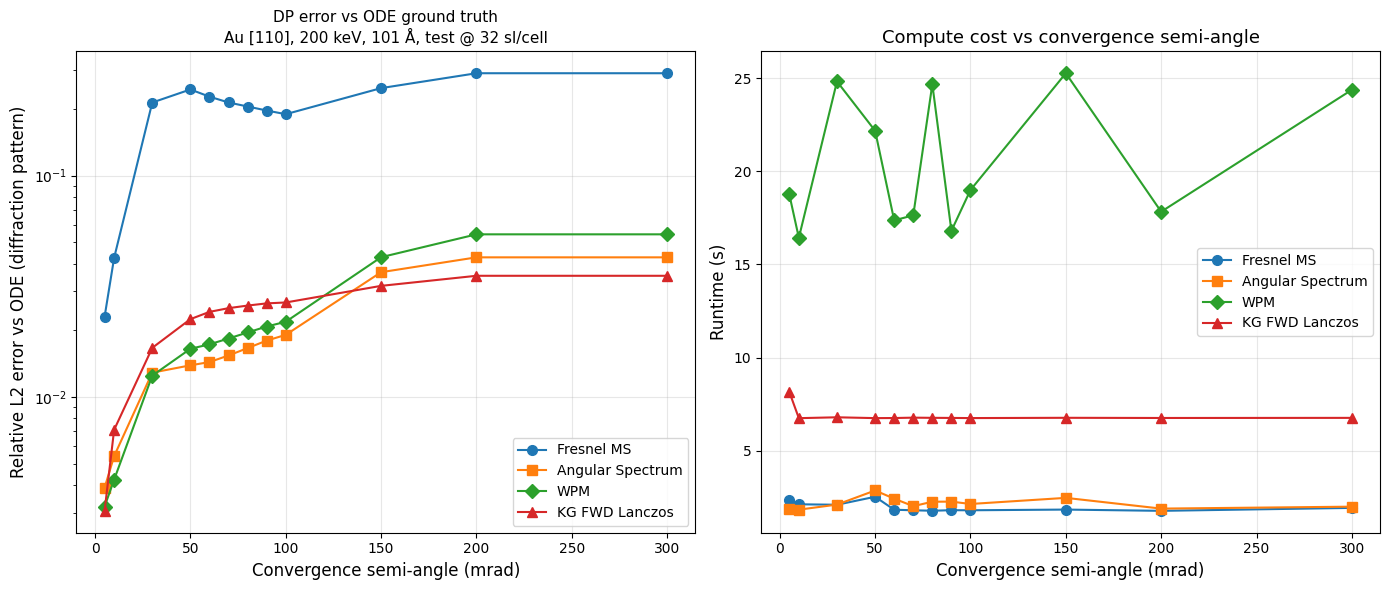

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

markers = {'Fresnel MS': 'o', 'Angular Spectrum': 's', 'WPM': 'D', 'KG FWD Lanczos': '^'}
colors = {'Fresnel MS': 'C0', 'Angular Spectrum': 'C1', 'WPM': 'C2', 'KG FWD Lanczos': 'C3'}

# Left: Rel L2 vs semi-angle
for name in method_names:
    ax1.semilogy(semi_angle_mrad, rel_l2_results[name], f'-{markers[name]}',
                 color=colors[name], label=name, markersize=7, linewidth=1.5)

ax1.set_xlabel("Convergence semi-angle (mrad)", fontsize=12)
ax1.set_ylabel("Relative L2 error vs ODE (diffraction pattern)", fontsize=12)
ax1.set_title(f"DP error vs ODE ground truth\nAu [110], {energy/1e3:.0f} keV, {total_thickness:.0f} Å, "
              f"test @ {TEST_SLICES_PER_CELL} sl/cell", fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Right: runtime vs semi-angle
for name in method_names:
    ax2.plot(semi_angle_mrad, timings[name], f'-{markers[name]}',
             color=colors[name], label=name, markersize=7, linewidth=1.5)

ax2.set_xlabel("Convergence semi-angle (mrad)", fontsize=12)
ax2.set_ylabel("Runtime (s)", fontsize=12)
ax2.set_title("Compute cost vs convergence semi-angle", fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Diffraction pattern comparison — selected convergence angles

Rows: 5, 20, 50, 100 mrad. Columns: ODE ground truth + test methods.

In [6]:
selected_angles_mrad = [5.0, 20.0, 50.0, 100.0]
selected_indices = [int(np.where(semi_angle_mrad == a)[0][0]) for a in selected_angles_mrad]

fig, axes = plt.subplots(
    len(selected_angles_mrad), len(method_names) + 1,
    figsize=(4 * (len(method_names) + 1), 3.5 * len(selected_angles_mrad))
)

for row, (alpha, idx) in enumerate(zip(selected_angles_mrad, selected_indices)):
    probe = make_convergent_probe(alpha, ny_g, nx_g, sampling[0], sampling[1], wavelength)

    # ODE ground truth
    ew_gt_here, _, dp_gt_raw_here, _ = simulate_kg_ode_full(
        pot_ode_arr, probe, dz_ode, energy, sampling,
        save_wavefronts=False,
    )
    dp_gt_here = np.asarray(dp_gt_raw_here)

    col_data, col_labels = [], []
    for name in method_names:
        if name == "Fresnel MS":
            result = simulate_fresnel_as(pot_test_arr, probe, fk, dz_test, energy)
        elif name == "Angular Spectrum":
            result = simulate_fresnel_as(pot_test_arr, probe, ak, dz_test, energy)
        elif name == "WPM":
            result = simulate_wpm(pot_test_arr, probe, dz_test, energy, sampling)
        else:
            result = (simulate_kg_fwd_lanczos(pot_test_arr, probe, dz_test, energy, sampling), None, None)
        dp = np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(result[0])))) ** 2
        col_data.append(dp)
        col_labels.append(name)

    vmax = np.percentile(dp_gt_here, 99.9)
    vmin = max(vmax * 1e-5, dp_gt_here[dp_gt_here > 0].min())

    axes[row, 0].imshow(dp_gt_here, norm=LogNorm(vmin=vmin, vmax=vmax), cmap="inferno", origin="lower")
    axes[row, 0].set_title(f"ODE GT\n{alpha:.0f} mrad", fontsize=9)
    axes[row, 0].axis("off")

    for col, (dp, label) in enumerate(zip(col_data, col_labels)):
        rl2 = rel_l2_results[label][idx]
        axes[row, col + 1].imshow(dp, norm=LogNorm(vmin=vmin, vmax=vmax), cmap="inferno", origin="lower")
        axes[row, col + 1].set_title(f"{label}\nRel L2={rl2:.2e}", fontsize=9)
        axes[row, col + 1].axis("off")

plt.suptitle(
    f"CBED patterns — Au [110], {energy/1e3:.0f} keV, {total_thickness:.0f} Å\n"
    f"ODE ground truth ({ODE_SLICES_PER_CELL} sl/cell), test methods at {TEST_SLICES_PER_CELL} sl/cell",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

## Summary table

In [ ]:
print(f"Au [110], {energy/1e3:.0f} keV, {total_thickness:.0f} Å")
print(f"Ground truth: KG ODE (full 2nd-order) at gpts={ODE_GPTS}, dz = {dz_ode:.4f} Å ({ODE_SLICES_PER_CELL} sl/cell)")
print(f"Test methods: dz = {dz_test:.4f} Å ({TEST_SLICES_PER_CELL} slices/cell)\n")

hdr = f"{'Semi-angle (mrad)':>18s}"
for name in method_names:
    hdr += f" {name:>17s}"
hdr += f" {'ODE GT time (s)':>16s}"
print(hdr)
print("-" * len(hdr))

for i, alpha in enumerate(semi_angle_mrad):
    row = f"{alpha:>18.0f}"
    for name in method_names:
        row += f" {rel_l2_results[name][i]:>17.4e}"
    row += f" {gt_timings[i]:>16.1f}"
    print(row)

Au [110], 200 keV, 101 Å
Ground truth: KG ODE (full 2nd-order) at gpts=(128, 128), dz = 0.0225 Å (128 sl/cell)
Test methods: dz = 0.0901 Å (32 slices/cell)

 Semi-angle (mrad)        Fresnel MS  Angular Spectrum               WPM    KG FWD Lanczos  ODE GT time (s)
-----------------------------------------------------------------------------------------------------------
                 5        2.3037e-02        3.8891e-03        3.2019e-03        3.0612e-03             46.7
                10        4.2500e-02        5.4070e-03        4.2330e-03        7.1087e-03             40.6
                20        1.1842e-01        9.7701e-03        8.7927e-03        1.9887e-02             40.3
                30        2.1375e-01        1.2882e-02        1.2489e-02        1.6673e-02             40.7
                40        2.5236e-01        1.3563e-02        1.5101e-02        1.9204e-02             40.1
                50        2.4488e-01        1.3901e-02        1.6512e-02        2.2472e